<a target="_blank" href="https://colab.research.google.com/github/seap-udea/pryngles/blob/kiss/tutorials/Quickstart-RingedPlanet.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Pryngles Quickstart (README)

This notebook contains *only* the Quickstart section from `README.md` (text + code), reproduced as-is for easy execution.

# Execution environment

This code only runs if you are in Google Colab.

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !sudo pip install -Uq pryngles

## 1. Import libraries

In [1]:
import pryngles as pr
from pryngles import Consts

> **NOTE**: If you are working in `GoogleColab` before producing any plot please load the 
  matplotlib backend:

  ```python
  %matplotlib inline
  ```

Any calculation in `Pryngles` starts by creating a planetary system:

(If you are using a notebook preview that does not automatically render Matplotlib figures, make sure you executed the `%matplotlib inline` cell above.)

In [2]:
%matplotlib inline

In [3]:
sys = pr.System()

S = sys.add(kind = "Star", radius = Consts.rsun/sys.ul, limb_coeffs = [0.65])
P = sys.add(kind = "Planet",parent = S, a = 0.2, e = 0.0, radius = Consts.rsaturn/sys.ul)
R = sys.add(kind = "Ring", parent = P, fi = 1.5, fe = 2.5, i = 30*Consts.deg)

In the example before the planet has a ring extending from 1.5 to 2.5
planetary radius which is inclined 30 degrees with respect to the
orbital plane. It has an orbit with semimajor axis of 0.2 and
eccentricity 0.0.

> **NOTE:** The following section implements our previous `RingedPlanet` interface, which is limited to modeling simple systems. If you would like to use our new, still-in-development interface `System`, please refer to our [Tutorials](../tutorials/tutorials.html) section.

Once the system is set we can *ensamble* a simulation, ie. creating an
object able to produce a light-curve.

To see how the surface of the planet and the rings looks like run:

You may change the position of the star in the orbit and see how the
appearance of the planet changes:

Below is the sequence of commands to produce your first light curve:

In [4]:
RP = sys.ensamble_system()

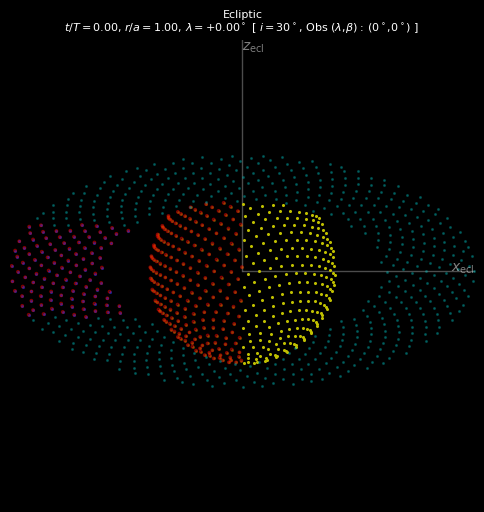

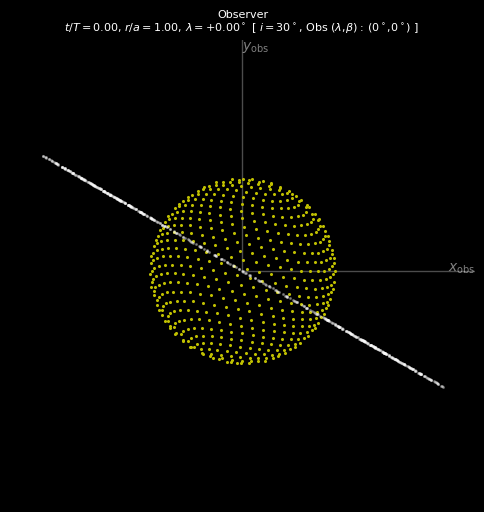

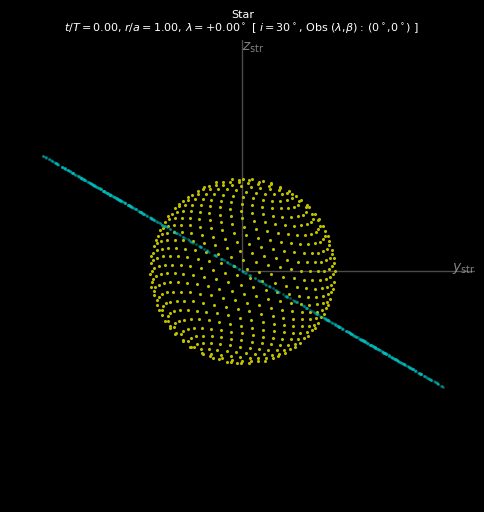

In [5]:
fig1, fig2, fig3 = RP.plotRingedPlanet()

You can change the stellar position:

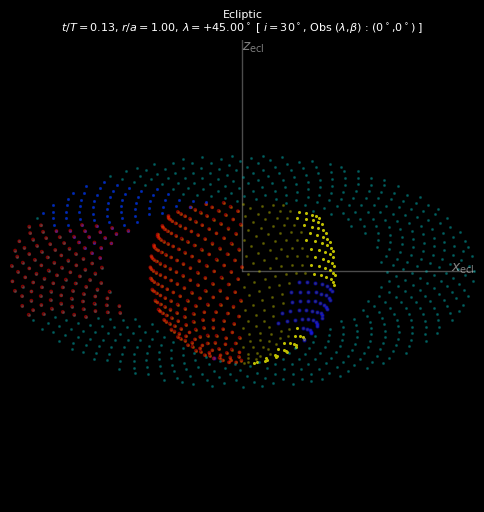

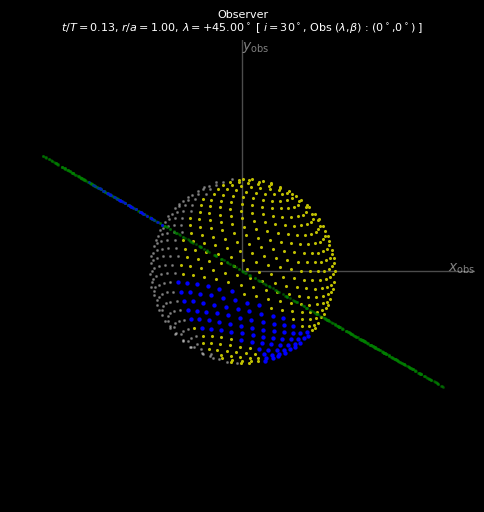

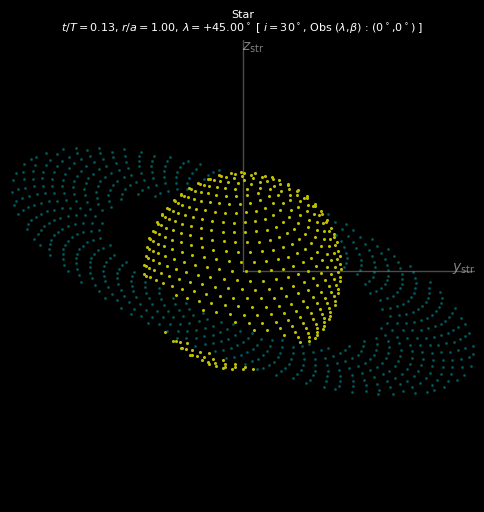

In [6]:
RP.changeStellarPosition(45*Consts.deg)
fig1, fig2, fig3 = RP.plotRingedPlanet()

Now we can create a light curve of the reflected light:

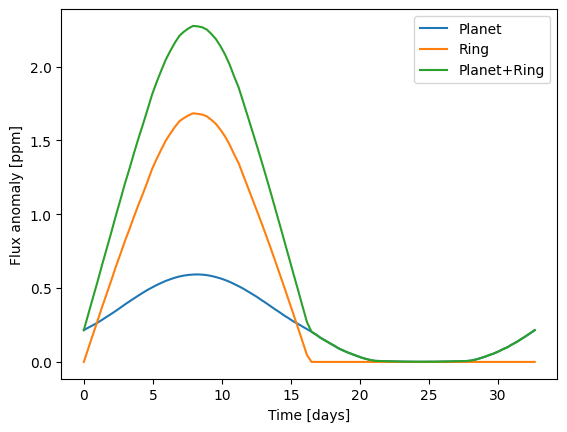

In [7]:
import numpy as np

RP.changeObserver([90*Consts.deg, 30*Consts.deg])
lambs = np.linspace(0.0*Consts.deg, 360*Consts.deg, 100)
Rps = []
Rrs = []
ts = []

for lamb in lambs:
    RP.changeStellarPosition(lamb)
    ts += [RP.t*sys.ut/Consts.day]
    RP.updateOpticalFactors()
    RP.updateDiffuseReflection()
    Rps += [RP.Rip.sum()]
    Rrs += [RP.Rir.sum()]

ts = np.array(ts)
Rps = np.array(Rps)
Rrs = np.array(Rrs)

#Plot
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.gca()
ax.plot(ts, Consts.ppm*Rps, label = "Planet")
ax.plot(ts, Consts.ppm*Rrs, label = "Ring")
ax.plot(ts, Consts.ppm*(Rps + Rrs), label = "Planet+Ring")

ax.set_xlabel("Time [days]")
ax.set_ylabel("Flux anomaly [ppm]")
ax.legend();
plt.show()


## Realistic Scattering and Polarization

Starting in version 0.9.x, Pryngles is able to compute fluxes using a
more realistic model for scattering that includes polarization. The
new features are not yet flexible enough but they can be used to
create more realistic light curves.

These new features are based on the science and Fortran code developed
by Prof. Daphne Stam and collaborators, and adapted to Pryngles
environment by Allard Veenstra (Fortran and Python wrapping) and Jorge
I. Zuluaga (translation to C and `ctypes`). For the science behind the
scattering and polarization code see:

> Rossi, L., Berzosa-Molina, J., & Stam, D. M. (2018). PyMieDAP: a
  Python–Fortran tool for computing fluxes and polarization signals of
  (exo) planets. Astronomy & Astrophysics, 616,
  A147. [arXiv:1804.08357](https://arxiv.org/abs/1804.08357)

Below is a simple example of how to compute the light curve of a
ringed planet whose atmosphere and ring scatters reallistically the
light of the star. The code compute the components of the Stokes
vector and the degree of polarization of the diffusely reflected light
on the system.

As shown in the example before, we first need to create the system:

In [8]:
nspangles = 1000

sys = pr.System()

S = sys.add(kind = "Star", radius = Consts.rsun/sys.ul, limb_coeffs = [0.65])
P = sys.add(kind = "Planet", primary = S, a = 3, e = 0.0, 
          radius = Consts.rsaturn/sys.ul, nspangles = nspangles)
R = sys.add(kind = "Ring", primary = P, fi = 1.5, fe = 2.25, 
          i = 30*Consts.deg, roll = 90*Consts.deg, nspangles = nspangles)

RP = sys.ensamble_system()

Then generate the light curve:

In [9]:
from tqdm import tqdm

RP.changeObserver([-90*Consts.deg, 60*Consts.deg])
lambs = np.linspace(90*Consts.deg, 450*Consts.deg, 181)

ts = []
Rps = []
Rrs = []
Pp  =  []
Pr  =  []
Ptot = []
for lamb in tqdm(lambs):
    RP.changeStellarPosition(lamb)
    ts += [RP.t*RP.CU.UT]
    RP.updateOpticalFactors()
    RP.updateReflection()
    Rps += [RP.Rip.sum()]
    Rrs += [RP.Rir.sum()]
    Pp +=  [RP.Ptotp]
    Pr +=  [RP.Ptotr]
    Ptot += [RP.Ptot]
    
ts = np.array(ts)
Rps = np.array(Rps)
Rrs = np.array(Rrs)
Pp = np.array(Pp)
Pr = np.array(Pr)
Ptot = np.array(Ptot)

100%|██████████| 181/181 [00:04<00:00, 40.16it/s]


And plot it:

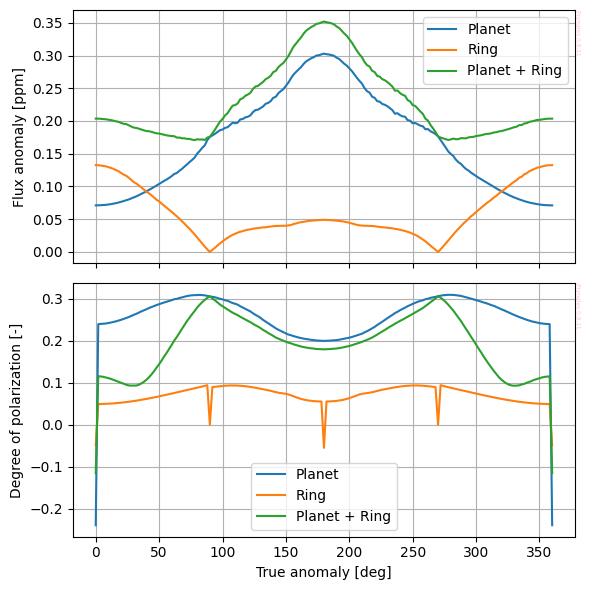

In [11]:
#Plot
fig, axs = plt.subplots(2, 1, figsize = (6, 6), sharex = True)

ax = axs[0]
ax.plot(lambs*180/np.pi-90, Rps, label = "Planet")
ax.plot(lambs*180/np.pi-90, Rrs, label = "Ring")
ax.plot(lambs*180/np.pi-90, Rps+Rrs, label = "Planet + Ring")
ax.set_ylabel("Flux anomaly [ppm]")
ax.legend()
ax.grid()
pr.Plot.pryngles_mark(ax)

ax = axs[1]
ax.plot(lambs*180/np.pi-90, Pp, label = "Planet")
ax.plot(lambs*180/np.pi-90, Pr, label = "Ring")
ax.plot(lambs*180/np.pi-90, Ptot, label = "Planet + Ring")
ax.set_ylabel("Degree of polarization [-]")
ax.legend()
ax.grid()
pr.Plot.pryngles_mark(ax)

ax = axs[1]
ax.set_xlabel("True anomaly [deg]")
fig.tight_layout()
plt.show()